# Import library

In [28]:
import os, math
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow import keras
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [ ]:
!nvidia-smi

In [29]:
dir_path = 'Dataset_brain_cancer'

train_dir = os.path.join(dir_path, 'train')
val_dir = os.path.join(dir_path, 'val')   
test_dir = os.path.join(dir_path, 'test')

In [30]:
Image_Size = (150, 150)
Batch_Size = 32
SEED = 42

In [31]:
train_ds = keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=Image_Size,
    batch_size=Batch_Size,
    color_mode="grayscale",
    shuffle=True
)

test_ds = keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=Image_Size,
    batch_size=Batch_Size,
    color_mode="grayscale",
    shuffle=True
)

val_ds = keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=Image_Size,
    batch_size=Batch_Size, 
    color_mode="grayscale",
    shuffle=True
)

Found 10497 files belonging to 3 classes.
Found 2253 files belonging to 3 classes.
Found 2250 files belonging to 3 classes.


In [32]:
train_ds.element_spec

(TensorSpec(shape=(None, 150, 150, 1), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

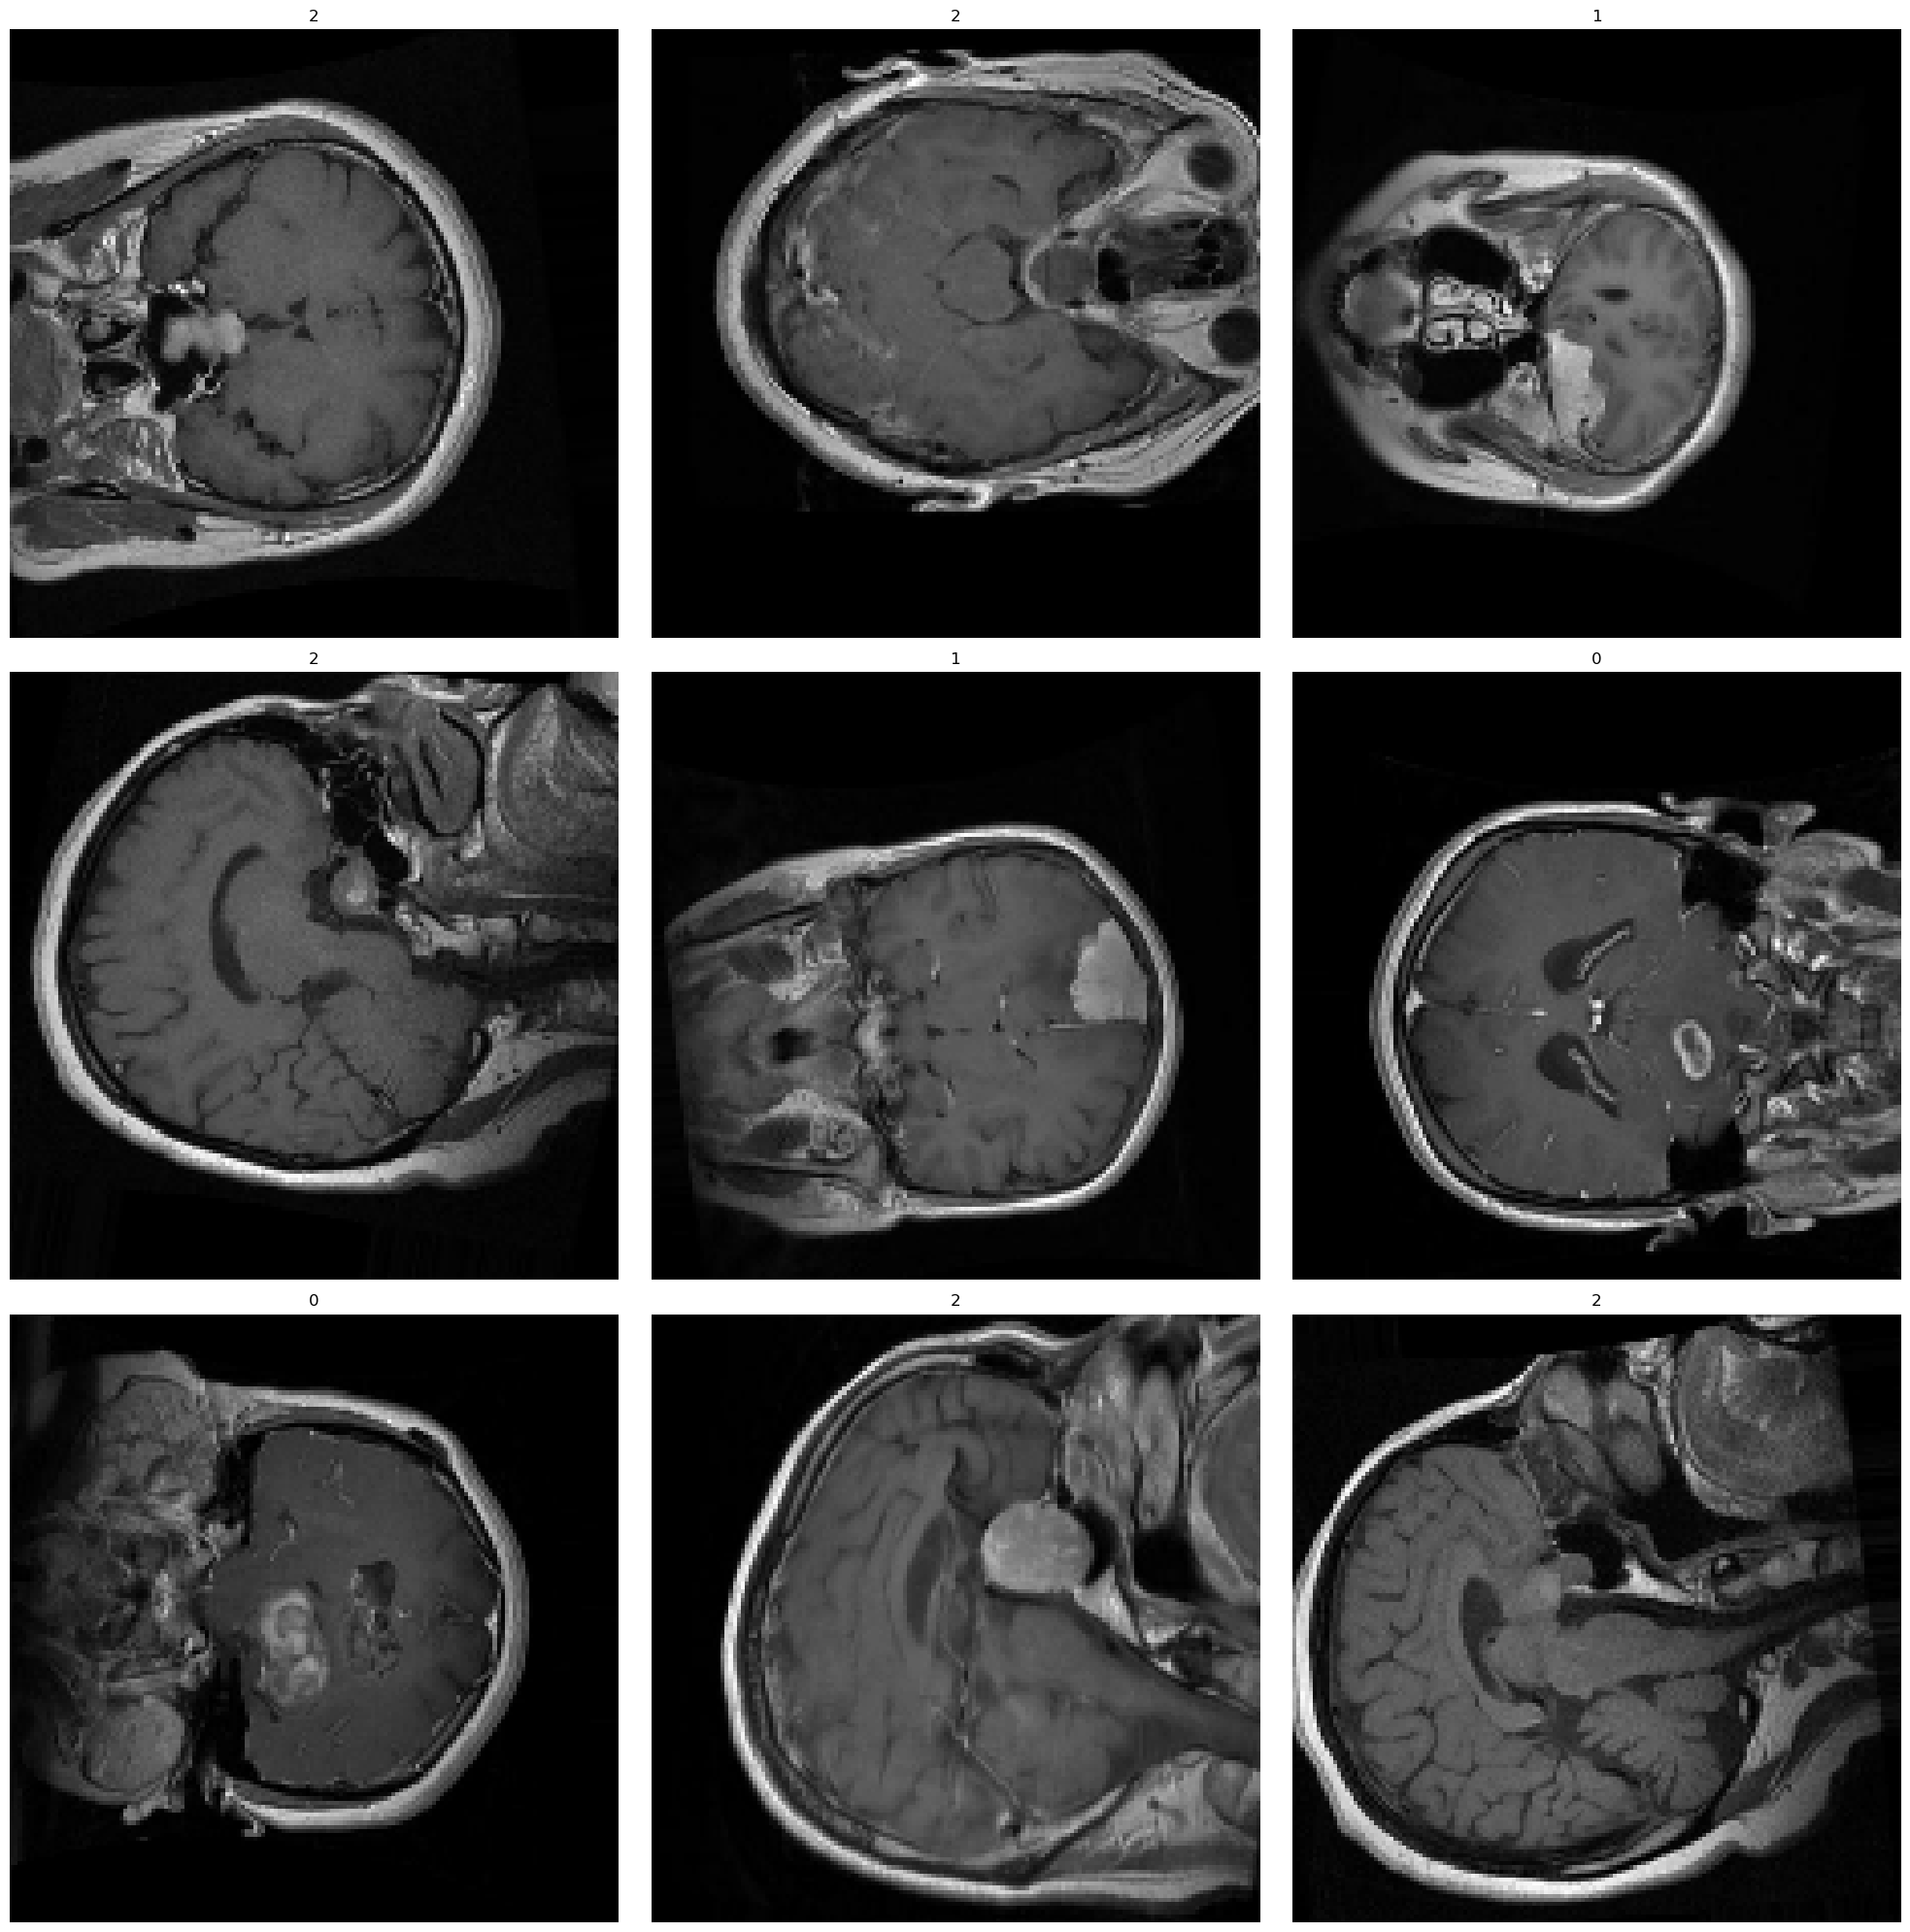

In [33]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
ax = ax.flatten()

for idx in range(9):
    img = images[idx].numpy().astype("uint8")
    ax[idx].imshow(img.squeeze(), cmap="gray") 
    ax[idx].set_title(labels[idx].numpy())
    ax[idx].axis("off")

plt.tight_layout()
plt.show()


In [34]:
class_names = train_ds.class_names
class_names

['brain_glioma', 'brain_menin', 'brain_tumor']

In [35]:
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)
val_da = val_ds.cache().prefetch(tf.data.AUTOTUNE)

# Augmentator

In [36]:
Augmentation = keras.Sequential([
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
], name="Augementator")

# Model

In [37]:
model = keras.Sequential([
    layers.Input(shape=Image_Size + (1,)),
    layers.Rescaling(1./255),
    Augmentation,

    layers.Conv2D(32, (3, 3), activation="relu", padding="same", kernel_initializer="he_normal"),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same", kernel_initializer="he_normal"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same", kernel_initializer="he_normal"),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same", kernel_initializer="he_normal"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same", kernel_initializer="he_normal"),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same", kernel_initializer="he_normal"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
    
])


In [38]:
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 150, 150, 1)       0         
                                                                 
 Augementator (Sequential)   (None, 150, 150, 1)       0         
                                                                 
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 


 conv2d_1 (Conv2D)           (None, 150, 150, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 75, 75, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 75, 75, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 37, 37, 64)       0         
 2D)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 37, 37, 64)        0         
          

# Callback options

In [39]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

# Train|

In [40]:
history = model.fit(
    x=train_ds,                
    epochs=50,                
    validation_data=val_ds,   
    callbacks=[early_stopping], 
    verbose=1                  
)

Epoch 1/50
329/329 [==============================] - 202s 568ms/step - loss: 0.9295 - accuracy: 0.5799 - val_loss: 0.8338 - val_accuracy: 0.6511
Epoch 2/50
329/329 [==============================] - 178s 539ms/step - loss: 0.7043 - accuracy: 0.7085 - val_loss: 0.7327 - val_accuracy: 0.7107
Epoch 3/50
329/329 [==============================] - 190s 578ms/step - loss: 0.6460 - accuracy: 0.7351 - val_loss: 1.0810 - val_accuracy: 0.5462
Epoch 4/50
329/329 [==============================] - 184s 559ms/step - loss: 0.5961 - accuracy: 0.7585 - val_loss: 0.8769 - val_accuracy: 0.6107
Epoch 5/50
329/329 [==============================] - 183s 555ms/step - loss: 0.5833 - accuracy: 0.7665 - val_loss: 0.8194 - val_accuracy: 0.6489
Epoch 6/50
329/329 [==============================] - 174s 529ms/step - loss: 0.5624 - accuracy: 0.7736 - val_loss: 0.7341 - val_accuracy: 0.6764
Epoch 7/50
329/329 [==============================] - 191s 581ms/step - loss: 0.5377 - accuracy: 0.7845 - val_loss: 0.7094 -

# Train and Validation Loss/Accuracy Graph

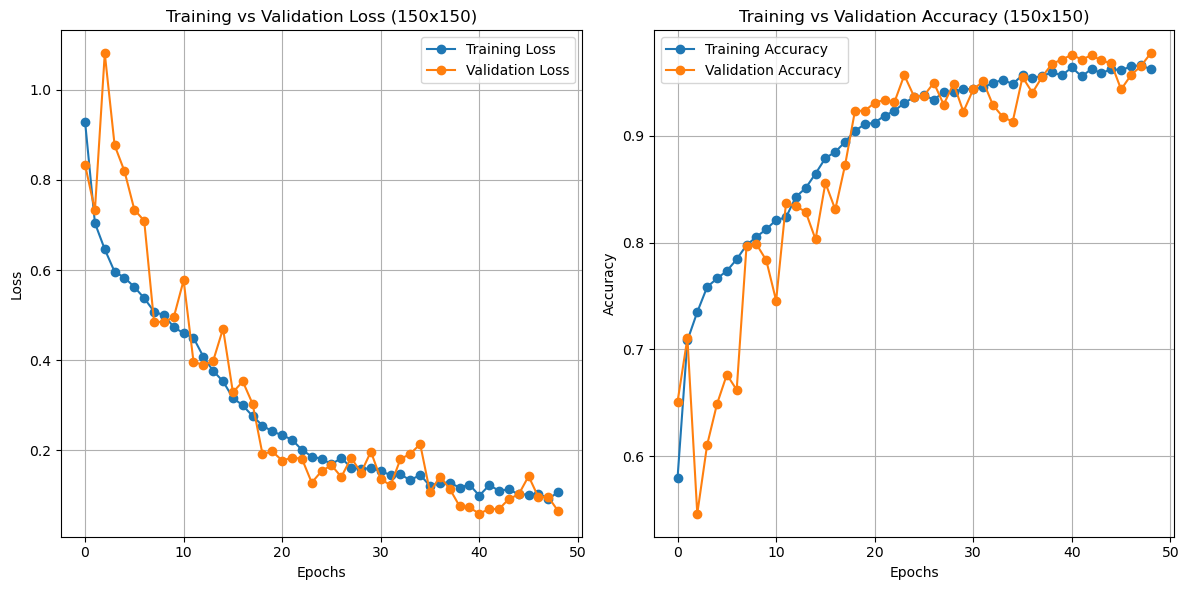

In [41]:
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

epochs_range = range(len(train_loss))

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss,   label='Validation Loss', marker='o')
plt.title(f'Training vs Validation Loss ({Image_Size[0]}x{Image_Size[1]})')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs_range, train_acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc,   label='Validation Accuracy', marker='o')
plt.title(f'Training vs Validation Accuracy ({Image_Size[0]}x{Image_Size[1]})')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid()

plt.tight_layout(); plt.show()

# Evaluation

In [42]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

71/71 [==============================] - 7s 98ms/step - loss: 0.0628 - accuracy: 0.9769
Test Loss: 0.0628 | Test Acc: 0.9769


# Confution metrix

In [47]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

In [44]:
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

In [48]:
print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro-F1: {macro_f1:.4f}")


Classification Report
              precision    recall  f1-score   support

brain_glioma     0.9866    0.9787    0.9826       751
 brain_menin     0.9783    0.9587    0.9684       751
 brain_tumor     0.9663    0.9933    0.9796       751

    accuracy                         0.9769      2253
   macro avg     0.9771    0.9769    0.9769      2253
weighted avg     0.9771    0.9769    0.9769      2253

Macro-F1: 0.9769


In [45]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

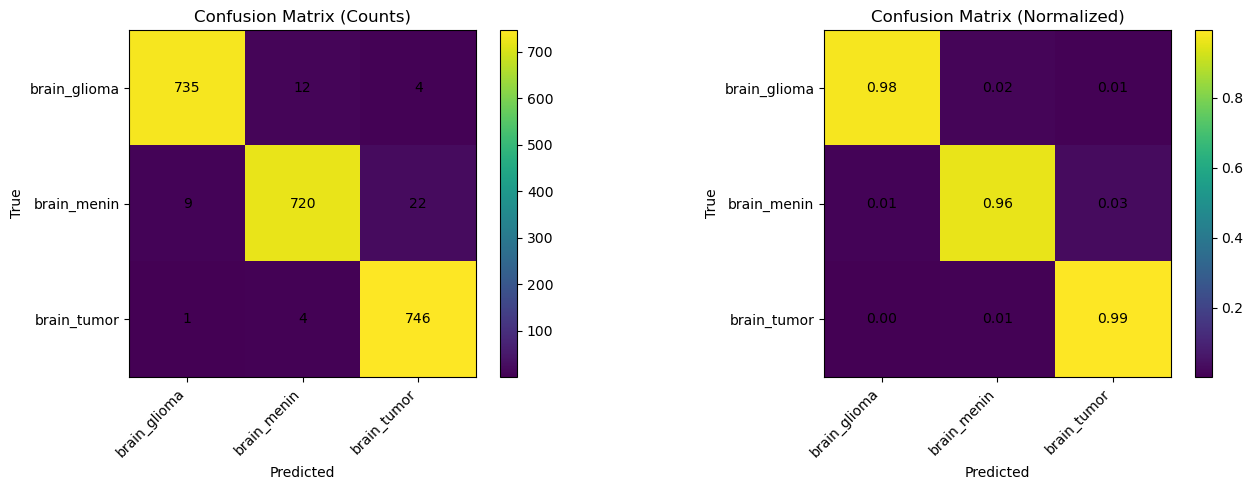

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

im0 = ax[0].imshow(cm, interpolation='nearest')
ax[0].set_title('Confusion Matrix (Counts)')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('True')
ax[0].set_xticks(np.arange(len(class_names))); ax[0].set_yticks(np.arange(len(class_names)))
ax[0].set_xticklabels(class_names, rotation=45, ha='right')
ax[0].set_yticklabels(class_names)
for (i, j), v in np.ndenumerate(cm):
    ax[0].text(j, i, str(v), ha='center', va='center')
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(cm_norm, interpolation='nearest')
ax[1].set_title('Confusion Matrix (Normalized)')
ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('True')
ax[1].set_xticks(np.arange(len(class_names))); ax[1].set_yticks(np.arange(len(class_names)))
ax[1].set_xticklabels(class_names, rotation=45, ha='right')
ax[1].set_yticklabels(class_names)
for (i, j), v in np.ndenumerate(cm_norm):
    ax[1].text(j, i, f"{v:.2f}", ha='center', va='center')
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()